In [4]:
import seaborn as sns
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [11]:
print(titanic.isnull().sum())
print(titanic.dtypes)
print(titanic.shape)
print(titanic.describe)

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object
(891, 15)
<bound method NDFrame.describe of      survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0     

In [14]:
import pandas as pd
# Survival rate by Sex
print("Survival by Sex:")
print(titanic.groupby('sex')['survived'].mean())

# Survival rate by Class
print("\nSurvival by Class:")
print(titanic.groupby('pclass')['survived'].mean())

# Age buckets banana
titanic['age_bucket'] = pd.cut(titanic['age'], 
                                bins=[0, 12, 18, 35, 60, 100],
                                labels=['Child', 'Teen', 'Adult', 'Middle Age', 'Senior'])

# Survival rate by Age bucket
print("\nSurvival by Age Bucket:")
print(titanic.groupby('age_bucket')['survived'].mean())

Survival by Sex:
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

Survival by Class:
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

Survival by Age Bucket:
age_bucket
Child         0.579710
Teen          0.428571
Adult         0.382682
Middle Age    0.400000
Senior        0.227273
Name: survived, dtype: float64


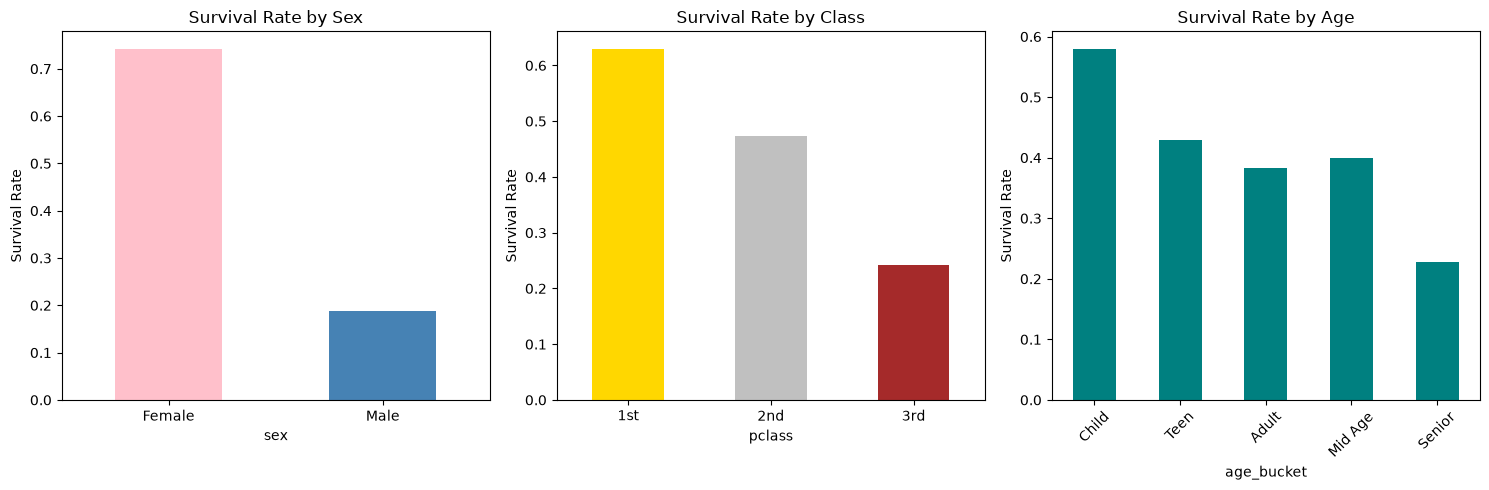

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Bar chart - Survival by Sex
titanic.groupby('sex')['survived'].mean().plot(kind='bar', ax=axes[0], color=['pink', 'steelblue'])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')
axes[0].set_xticklabels(['Female', 'Male'], rotation=0)

# Bar chart - Survival by Class
titanic.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[1], color=['gold', 'silver', 'brown'])
axes[1].set_title('Survival Rate by Class')
axes[1].set_ylabel('Survival Rate')
axes[1].set_xticklabels(['1st', '2nd', '3rd'], rotation=0)

# Bar chart - Survival by Age Bucket
titanic.groupby('age_bucket')['survived'].mean().plot(kind='bar', ax=axes[2], color='teal')
axes[2].set_title('Survival Rate by Age')
axes[2].set_ylabel('Survival Rate')
axes[2].set_xticklabels(['Child', 'Teen', 'Adult', 'Mid Age', 'Senior'], rotation=45)

plt.tight_layout()
plt.savefig('survival_analysis.png')
plt.show()

C:\Users\praja\AppData\Local\Temp\ipykernel_3304\3782219596.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='survived', y='age', data=titanic, ax=axes[0], palette='Set2')


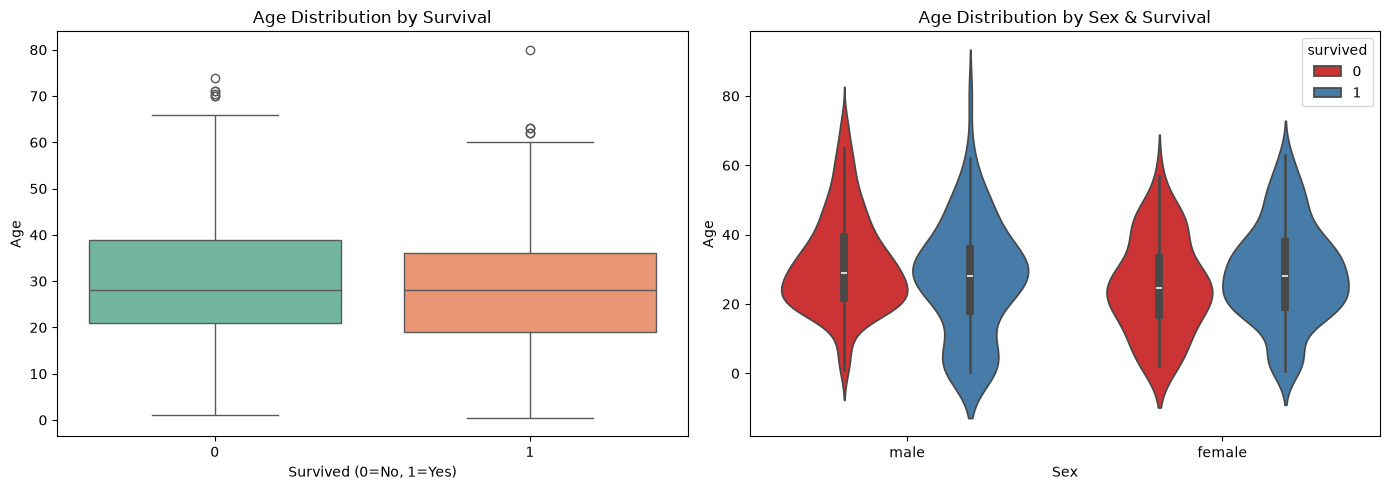

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot - Age by Survival
sns.boxplot(x='survived', y='age', data=titanic, ax=axes[0], palette='Set2')
axes[0].set_title('Age Distribution by Survival')
axes[0].set_xlabel('Survived (0=No, 1=Yes)')
axes[0].set_ylabel('Age')

# Violinplot - Age by Sex and Survival
sns.violinplot(x='sex', y='age', hue='survived', data=titanic, ax=axes[1], palette='Set1')
axes[1].set_title('Age Distribution by Sex & Survival')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.savefig('age_distribution.png')
plt.show()

In [21]:
report = """
TITANIC SURVIVAL ANALYSIS - INSIGHT REPORT
===========================================

- Female survival rate (74%) was much higher than male (18%) 
  — "Women and children first" policy clearly followed.

- 1st class passengers had highest survival rate (63%) vs 
  3rd class (24%) — wealth played a major role in survival.

- Children (0-12) had highest survival rate (58%) among age groups
  — priority was given to younger passengers.

- Seniors (60+) had lowest survival rate (22%) — possibly due to 
  difficulty in evacuation.

- Overall survival rate was only 38% — majority of passengers 
  did not survive the disaster.
"""

print(report)

with open('titanic_insight_report.txt', 'w') as f:
    f.write(report)

print("✅ Report saved!")


TITANIC SURVIVAL ANALYSIS - INSIGHT REPORT

- Female survival rate (74%) was much higher than male (18%) 
  — "Women and children first" policy clearly followed.

- 1st class passengers had highest survival rate (63%) vs 
  3rd class (24%) — wealth played a major role in survival.

- Children (0-12) had highest survival rate (58%) among age groups
  — priority was given to younger passengers.

- Seniors (60+) had lowest survival rate (22%) — possibly due to 
  difficulty in evacuation.

- Overall survival rate was only 38% — majority of passengers 
  did not survive the disaster.

✅ Report saved!
